In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
from torchviz import make_dot
from sklearn.datasets import make_moons

%matplotlib inline

ModuleNotFoundError: No module named 'torchviz'

# Agenda


1. [Intro to Deep Learning](#Intro)
   1. [Applications](#Applications)
   2. [Place of Deep Learning in Machine Learning](#Dl_and_ML)
   3. [Formalization](#Formalization)
2. [Pytorch](#Pytorch)
3. [Perceptron and Backpropagation](#Perceptron)


# Resources

- [Chat with ChatGPT](https://chatgpt.com/share/68ac6d40-9cd0-8003-8d93-d45ead06a4c1)
- [Ostap Viniavskyi Lecture about Pytorch and CNNs](https://github.com/VSydorskyy/ucu_audio_processing_course/blob/main/Module_2/Lecture_2/Intro_to_Pytorch.ipynb)
- [Volodymyr Sydorskyi Lecture about Intro to Audio ML](https://github.com/VSydorskyy/ucu_audio_processing_course/blob/main/Module_1/Lecture_1/Intro_to_Audio_ML.ipynb)
- [Volodymyr Sydorskyi Lecture about Intro to NLP](https://github.com/VSydorskyy/iasa_nlp_course/blob/main/Lecture_1/Formalization_of_Ml_task.ipynb)
- [Vladyslav Yelisieiev Lecture about Text Representations and ML Model Formalization](https://github.com/VSydorskyy/iasa_nlp_course/blob/main/Lecture_2/lecture2_text_repr_classic_ml.ipynb)
- [A Comparative Survey of PyTorch vs TensorFlow for Deep Learning: Usability, Performance, and Deployment Trade-offs](https://arxiv.org/html/2508.04035v1)


<a id='Intro'></a>

# Intro to Deep Learning


<a id='Applications'></a>

## Applications

### 1. Computer Vision

- **Medical Imaging** – tumor detection in CT/MRI, diabetic retinopathy screening, skin lesion classification. Examples: [Better Medicine](https://bettermedicine.ai/), [RSNA Intracranial Aneurysm Detection](https://www.kaggle.com/competitions/rsna-intracranial-aneurysm-detection), [ISIC 2024 - Skin Cancer Detection with 3D-TBP](https://www.kaggle.com/competitions/isic-2024-challenge)
- **Autonomous Vehicles** – object detection, lane following, pedestrian recognition.
- **Security & Surveillance** – facial recognition, anomaly detection in video feeds.
- **Industry** – defect detection in manufacturing.

---

### 2. Natural Language Processing (NLP)

- **Machine Translation** – Google Translate, DeepL.
- **Conversational AI** – chatbots, personal assistants like Siri or Alexa.
- **Sentiment Analysis** – analyzing reviews, social media, financial reports.
- **Document Processing** – summarization, search, retrieval, question answering. Examples: [Prog.AI](https://www.getprog.ai/)

---

### 3. Speech & Audio

- **Speech Recognition** – automatic transcription (ASR systems).
- **Speech Synthesis** – Text-to-Speech (TTS), voice cloning. Examples: [Respeecher](https://www.respeecher.com/), [Eleven Labs](https://elevenlabs.io/)
- **Audio Event Detection** – ecoacoustics (bird call detection), defense (drone/missile recognition). Examples: [Zvook](https://www.zvook.tech/ua)
- **Music Generation** – AI composers, intelligent sound design.

---

### 4. Generative AI

- **Image Generation** – Stable Diffusion, DALL·E.
- **Text Generation** – GPT models (chatbots, content creation).
- **Data Augmentation** – generating synthetic samples to boost model training.
- **Digital Twins** – simulating organs, environments, or mechanical systems.

---

### 5. Recommendation & Prediction Systems

- **Recommender Systems** – Netflix, YouTube, Spotify, Amazon.
- **Finance** – fraud detection, stock price prediction.
- **Healthcare** – personalized treatment recommendation.

---

### 6. Science & Engineering

- **Drug Discovery** – predicting protein structures (AlphaFold).
- **Climate & Environment** – weather forecasting, climate modeling.
- **Physics & Chemistry** – solving PDEs, material discovery.
- **Astronomy** – analyzing telescope data, galaxy classification.

---

### To Sum Up

**Deep Learning is applied when classical algorithms, rule-based approaches, machine learning algorithms do not cope with the task**


<a id='Dl_and_ML'></a>

## Place of Deep Learning in Machine Learning


![mlvd](https://github.com/mephistopheies/mlworkshop39_042017/raw/a6426fd652faa38864c3ea4538e000539106fb56/1_ml_intro/ipy/images/bengio.png)

**A series of possible taxonomies exists. One that looks the most reliable: AI is the most general sphere. ML is a subset of AI, which covers all "learnable" algorithms. Deep Learning is a subset of ML, which covers Artificial Neural Nets**


<a id='Formalization'></a>

## Formalization


## Predictive Model

_Model_ - parametric space of functions (hypotheses):

$\large \mathcal{H} = \left\{ h\left(x, \theta\right) | \theta \in \Theta \right\}$

- where
  - $\large h: X \times \Theta \rightarrow Y$
  - $\large \Theta$ - parametric space
  - $\large X$ - factor space (exogenous variables)
  - $\large Y$ - target space

### Training algorithm

_Training algorithm_ - map from data space to hypotheses space:

$\large \mathcal{M}: X \times Y \rightarrow \mathcal{H}$

There are 2 steps in algorithm:

1. Selection of hypothesis: $\large h = \mathcal{M}\left(D\right)$, where $\large D$ - our particular dataset
2. Testing for given example $\large x$ calculation of model prediction $\large \hat{y} = h\left(x\right)$

### Selection of hypothesis

Define real-valued _loss function_:
$\large L: Y \times Y \rightarrow \mathbb{R}$ <br>

With loss function we can measure how the prediction $\large \hat {y}$ differs from the ground truth values $\large y$.

The risk of the hypothesis $\large h$ is the expected value of the error function according to the distribution of examples:
$$\large Q(h)= \mathbb{E}_{(x, y) \sim P(x, y)}\left[ L(h(x), y) \right] = \int L(h(x), y) \, dP(x, y) $$

Unfortunately, the joint density $\large P(x,y)$ is unknown (otherwise there would be no problem). But we can compute an approximation of the expression above as the mean of the sample cost function (empirical risk).

$\large Q_{\text{emp}}\left(h\right) = \frac{1}{n} \sum_{i=1}^n L\left(h\left(x_i\right), y_i\right)$,
where $\large \mathcal{D} = \left\{ \left(x_i, y_i\right) \right\}$ - our training dataset, $\large h$ - hypothesis (function)

We should select hypothesis, that minimizes average loss:
$\large \hat{h} = \arg \min_{h \in \mathcal{H}} Q_{\text{emp}}\left(h\right)$

Examples of loss functions:

- classification: $\large L\left(\hat{y}, y\right) = \text{I}\left[\hat{y} = y\right]$
- regression: $\large L\left(\hat{y}, y\right) = \left(\hat{y} - y\right)^2$

The main disadvantage of the empirical risk minimization principle is overfitting:

- the model has a generalizing ability if the probability of an error on the test data set (such a set of examples that did not participate in training in any form) is small or predictable.
- overfitting is the fact that the model shows very good results on the training set and bad on the test set. Such models do not have a generalizing ability.


**Supervised learning** - the task of deriving a function
\begin{gather*}
f: X \to Y
\end{gather*}
from a given labeled data; each example is a pair of the feature vector of the object and the desired response to it
\begin{gather*}
D = \{(x_i, y_i)\}, i=1,...,n;
\end{gather*}
for example the target variable could be:

- categorical - the task of classification;
- continuous - regression task;
- ordinal - ranking task.

**Unsupervised learning** - the task of deriving a function that describes the internal structure of unlabeled data
\begin{gather*}
D = \{x_i\}, i=1,...,n;
\end{gather*}

for example:

- clustering - the task of identifying hidden groups within the data;
- dimension compression - the task of reducing the number of features;
- filling gaps in the matrix - the task of recommendations;
- partial learning - the task of supervised learning, subject to unlimited access to unlabeled data and an extremely limited set of labeled ones.


<a id='Pytorch'></a>

# Pytorch


## Introduction to Pytorch

PyTorch is an open-source deep learning framework developed by **Meta AI (formerly Facebook AI Research)**. It provides a flexible and efficient platform for building and training neural networks, making it widely used in both research and industry. At its core, PyTorch offers **tensor computation with strong GPU acceleration** and an **automatic differentiation system** (`autograd`), which simplifies gradient-based optimization for deep learning models.

PyTorch excels in **dynamic computation graphs**, allowing users to modify models on the fly, making it highly suitable for applications such as **natural language processing (NLP), computer vision, and reinforcement learning**. The framework provides built-in support for popular deep learning tasks, including **convolutional neural networks (CNNs), recurrent neural networks (RNNs), and transformer-based architectures**.

However, PyTorch does have some limitations. While it is efficient for research and prototyping, its deployment options were traditionally less optimized compared to static graph frameworks like TensorFlow. That said, **TorchScript** and **PyTorch’s integration with ONNX (Open Neural Network Exchange)** have significantly improved its deployment capabilities. Additionally, PyTorch requires **manual optimization for large-scale distributed training**, which can be complex compared to frameworks designed specifically for production environments.

Despite these challenges, PyTorch remains one of the most popular frameworks due to its ease of use, strong community support, and extensive ecosystem, including **TorchVision (for computer vision tasks), TorchText (for NLP), and TorchAudio (for audio processing)**.

**Differences Between PyTorch and NumPy**

PyTorch and NumPy both provide powerful tensor computation capabilities, but PyTorch extends NumPy's functionality by **supporting GPU acceleration** and **automatic differentiation**. While NumPy arrays (`ndarray`) are optimized for general numerical computing, PyTorch tensors (`torch.Tensor`) are designed specifically for deep learning, allowing seamless computation on both CPUs and GPUs. Additionally, PyTorch’s `autograd` module enables automatic differentiation, making it easier to compute gradients and train neural networks, whereas NumPy requires explicit differentiation implementations. Despite these differences, PyTorch tensors and NumPy arrays share a similar interface, and conversion between them is straightforward using `.numpy()` and `torch.from_numpy()`.

![mlvd](images/Pytorch_Tf.png)

Taken from [A Comparative Survey of PyTorch vs TensorFlow for Deep Learning: Usability, Performance, and Deployment Trade-offs](https://arxiv.org/html/2508.04035v1)


## Basic Operations


In [ ]:
torch.manual_seed(0)

In [ ]:
if torch.cuda.is_available():
    device = "cuda:0"
    print('CUDA is available. Setting device="cuda"')

else:
    device = "cpu"
    print('CUDA is not available. Setting device="cpu"')

CUDA is available. Setting device="cuda"


In [ ]:
# create torch tensor from scalar value
x = torch.tensor(0.0)
print(f"{x.device=}", f"{x.shape=}", f"{x.dtype=}")

# create 2x2 matrix
M = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(f"{M.device=}", f"{M.shape=}", f"{M.dtype=}")

x.device=device(type='cpu') x.shape=torch.Size([]) x.dtype=torch.float32
M.device=device(type='cpu') M.shape=torch.Size([2, 2]) M.dtype=torch.float32


In [ ]:
# move tensor to another device, convert dtype to int64
M1 = M.to(device, dtype=torch.int64)
print(f"{M1.device=}", f"{M1.dtype=}")

# reshape tensor
M2 = M1.reshape(1, 4)
print(f"{M2.shape=}")

M1, M2

M1.device=device(type='cuda', index=0) M1.dtype=torch.int64
M2.shape=torch.Size([1, 4])


(tensor([[1, 2],
         [3, 4]], device='cuda:0'),
 tensor([[1, 2, 3, 4]], device='cuda:0'))

In [ ]:
# elementwise operations
A = torch.randn(3, 4)
B = torch.randn(3, 4)

C = A + B
print(C.shape)

try:
    C = A + B.T
except Exception as e:
    print(type(e), e)

torch.Size([3, 4])
<class 'RuntimeError'> The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 1


In [ ]:
# matrix mulitplication
A = torch.randn(3, 4)
B = torch.randn(3, 4)

D = torch.matmul(A, B.T)
print(D.shape)

try:
    C = torch.matmul(A, B)
except Exception as e:
    print(type(e), e)

NameError: name 'torch' is not defined

## Intro to Autograd

PyTorch's **Autograd** is an automatic differentiation engine that plays a crucial role in optimizing deep learning models. It allows for efficient gradient computation by tracking operations performed on tensors and dynamically constructing a **computational graph** in the background.

**Computational Graph**

A **computational graph** is a directed acyclic graph (DAG) where nodes represent mathematical operations, and edges represent the flow of data (tensors). When performing operations on tensors with `requires_grad=True`, PyTorch builds this graph dynamically, recording the sequence of operations for efficient gradient computation during **backpropagation**.

**Static vs. Dynamic Computational Graphs**

| Feature           | Static Graph (e.g., TensorFlow v1)                 | Dynamic Graph (PyTorch)                                       |
| ----------------- | -------------------------------------------------- | ------------------------------------------------------------- |
| Graph Definition  | Defined before execution                           | Built dynamically during execution                            |
| Flexibility       | Less flexible, requires re-compilation for changes | Highly flexible, allowing model modifications on the fly      |
| Debugging         | More complex, requires specialized tools           | Easier, as it integrates with Python’s native debugging tools |
| Memory Efficiency | Can be optimized before execution                  | May use more memory due to dynamic allocation                 |

PyTorch's dynamic computation graph allows for more intuitive and flexible model development, particularly useful for tasks like **variable-length sequences and reinforcement learning**.

**Forward vs. Backward Automatic Differentiation**

![](images/forward_autodif.png) <br>

1. **Forward Mode Differentiation**
   - Computes derivatives **from inputs to outputs**.
   - Efficient when the number of inputs is **small**, but outputs are large.
   - Less commonly used in deep learning but useful in some scientific computing applications.

![](images/backward_autodif.png) <br> 2. **Backward Mode Differentiation (Reverse Mode Differentiation)**

- Computes derivatives **from outputs back to inputs**.
- Efficient for deep learning, where the number of outputs (loss scalar) is much smaller than the number of parameters.
- PyTorch primarily uses **backward differentiation** for backpropagation.

PyTorch’s `autograd` enables efficient **backward differentiation** by calling `.backward()` on a scalar loss, computing gradients for all tensors involved in the computation.


For **inference**, Conv + BatchNorm can be algebraically collapsed into a new convolution.

BatchNorm after convolution can be written as:

$$
y =
\gamma
\frac{Wx + b - \mu}
{\sqrt{\sigma^2 + \epsilon}}
+ \beta
$$

Define new convolution weights:

$$
W' =
\frac{\gamma}
{\sqrt{\sigma^2 + \epsilon}}
W
$$

and new bias:

$$
b' =
\frac{\gamma}
{\sqrt{\sigma^2 + \epsilon}}
(b - \mu)
+ \beta
$$

Then:

$$
\operatorname{BN}(\operatorname{Conv}(x))
=
\operatorname{Conv}(x; W', b')
$$

Therefore, during inference:

```text
Conv → BatchNorm → ReLU
```


## Logistic Regression and Reverse Mode Differentiation

Logistic regression is a binary classification model that predicts the probability of an input belonging to a certain class. Given an input **vector** $\mathbf{x} \in \mathbb{R}^m$ with **m features**, the model computes the probability using the **sigmoid activation function**:

$$
y = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

where

$$
z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^{m} w_i x_i + b
$$

- $\mathbf{w} \in \mathbb{R}^m$ is the weight vector
- $b \in \mathbb{R}$ is the bias term
- $\sigma(z)$ is the sigmoid function, which maps $z$ to the range $(0,1)$

The loss function for logistic regression is the **binary cross-entropy loss**, given by:

$$
L = - \left( y_{\text{true}} \log y + (1 - y_{\text{true}}) \log (1 - y) \right)
$$

where $y_{\text{true}}$ is the ground truth label.

**Reverse Mode Differentiation (Backpropagation)**

To train the model, we need to compute the **gradients** of the loss $L$ with respect to each **weight value** $w_i$ and bias $b$. Using reverse mode differentiation, we compute derivatives step by step.

**Step 1: Compute $\frac{dL}{dy}$**

$$
\frac{dL}{dy} = - \left( \frac{y_{\text{true}}}{y} - \frac{1 - y_{\text{true}}}{1 - y} \right)
$$

**Step 2: Compute $\frac{dy}{dz}$ (Derivative of Sigmoid)**

$$
\frac{dy}{dz} = \sigma(z) (1 - \sigma(z)) = y (1 - y)
$$

**Step 3: Compute $\frac{dz}{dw_i}$**

$$
\frac{dz}{dw_i} = x_i
$$

**Step 4: Compute $\frac{dL}{dw_i}$ using Chain Rule**

By applying the chain rule:

$$
\frac{dL}{dw_i} = \frac{dL}{dy} \cdot \frac{dy}{dz} \cdot \frac{dz}{dw_i}
$$

Substituting the values:

$$
\frac{dL}{dw_i} = \left( - \frac{y_{\text{true}}}{y} + \frac{1 - y_{\text{true}}}{1 - y} \right) \cdot y (1 - y) \cdot x_i
$$

**Step 5: Interpretation**

This derivative tells us how much the loss changes with respect to each input $w_i$. It is used in **gradient-based optimization algorithms**, such as **stochastic gradient descent (SGD)**, to update the model parameters.


In [ ]:
# simulate logistic regression set-up
weights_require_grad = True  # set to True to avoid error

# input data X and label y
X = torch.randn(100, 3)
y_true = torch.randint(2, size=(100,))

# weights wector w and bias b
w = torch.randn(3, requires_grad=weights_require_grad)
b = torch.randn(1, requires_grad=weights_require_grad)

# compute y_pred
y = torch.sigmoid(X @ w + b)

# compute binary cross-entropy loss
loss = -(1 - y_true) * torch.log(1 - y) - y_true * torch.log(y)
loss = loss.sum()
loss.backward()

In [ ]:
y_true.shape

torch.Size([100])

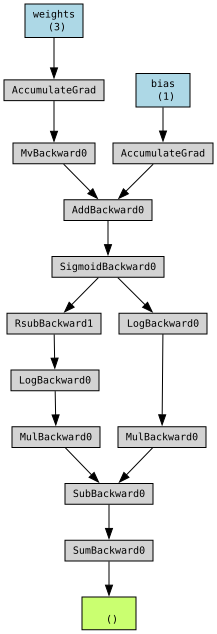

In [ ]:
make_dot(loss, params=dict(weights=w, bias=b))

In [ ]:
# print grads
print(f"{w.grad=}")
print(f"{b.grad=}")
print(f"{y.grad=}")

w.grad=tensor([-4.1223,  0.5713,  8.4531])
b.grad=tensor([8.8371])
y.grad=None


/tmp/ipykernel_1481106/1255249821.py:4: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /__w/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:493.)
  print(f"{y.grad=}")


In [ ]:
# check that autodiff results correspond to manually derived values
with torch.no_grad():
    w_grad = (-y_true / y + (1 - y_true) / (1 - y)) * y * (1 - y) @ X
    b_grad = ((-y_true / y + (1 - y_true) / (1 - y)) * y * (1 - y)).sum()

print(f"{w_grad=}")
print(f"{b_grad=}")

w_grad=tensor([-4.1223,  0.5713,  8.4531])
b_grad=tensor(8.8371)


<a id='Perceptron'></a>

# Perceptron and Backpropagation


## Generate dataset


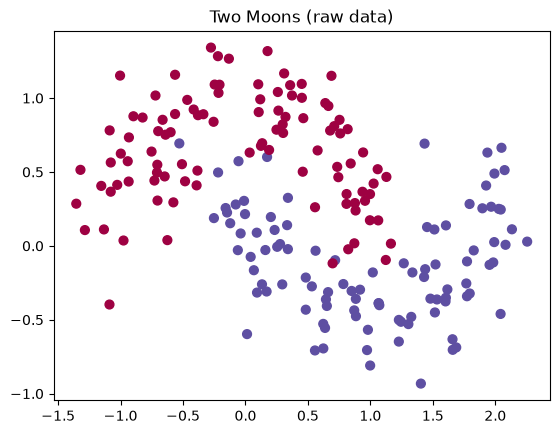

In [ ]:
X_np, y_np = make_moons(200, noise=0.20, random_state=0)
X = torch.tensor(X_np, dtype=torch.float32)  # (N, 2)
y = torch.tensor(y_np, dtype=torch.float32).view(
    -1, 1
)  # shape (N, 1) for binary labels

N, D = X.shape

plt.figure()
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), s=40, c=y_np, cmap=plt.cm.Spectral)
plt.title("Two Moons (raw data)")
plt.show()

## Build Perceptron


In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + torch.exp(-x))


def relu(x):
    return torch.clamp(x, min=0.0)


class MLP(torch.nn.Module):
    def __init__(self, layer_sizes, manual_optimization=True):
        super().__init__()
        # layer_sizes: [input_dim, hidden1, hidden2, output_dim]
        assert len(layer_sizes) == 4
        D_in, H1, H2, D_out = layer_sizes

        if manual_optimization:
            self.W1 = torch.randn(D_in, H1)
            self.b1 = torch.zeros(1, H1)
            self.W2 = torch.randn(H1, H2)
            self.b2 = torch.zeros(1, H2)
            self.W3 = torch.randn(H2, D_out)
            self.b3 = torch.zeros(1, D_out)
            for p in [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]:
                p.requires_grad_(False)
        else:
            self.W1 = torch.nn.Parameter(torch.randn(D_in, H1))
            self.b1 = torch.nn.Parameter(torch.zeros(1, H1))
            self.W2 = torch.nn.Parameter(torch.randn(H1, H2))
            self.b2 = torch.nn.Parameter(torch.zeros(1, H2))
            self.W3 = torch.nn.Parameter(torch.randn(H2, D_out))
            self.b3 = torch.nn.Parameter(torch.zeros(1, D_out))

    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = relu(Z1)
        Z2 = A1 @ self.W2 + self.b2
        A2 = relu(Z2)
        logits = A2 @ self.W3 + self.b3
        probs = torch.sigmoid(logits)  # sigmoid output, shape (N,1)
        cache = {
            "X": X,
            "Z1": Z1,
            "A1": A1,
            "Z2": Z2,
            "A2": A2,
            "logits": logits,
            "probs": probs,
        }
        return probs, cache

    def loss(self, y_true, probs):
        # Binary cross-entropy
        eps = 1e-12
        bce = -(
            y_true * torch.log(probs + eps) + (1 - y_true) * torch.log(1 - probs + eps)
        )
        data_loss = bce.mean()
        return data_loss

    def backward(self, cache, y_true):
        X, Z1, A1, Z2, A2, logits, probs = (
            cache["X"],
            cache["Z1"],
            cache["A1"],
            cache["Z2"],
            cache["A2"],
            cache["logits"],
            cache["probs"],
        )
        N = X.shape[0]

        # derivative of BCE wrt logits = (probs - y) / N
        dlogits = (probs - y_true) / N  # (N,1)

        # W3, b3
        dW3 = A2.T @ dlogits
        db3 = dlogits.sum(dim=0, keepdim=True)

        # backprop to A2
        dA2 = dlogits @ self.W3.T
        dZ2 = dA2 * (Z2 > 0).float()

        # W2, b2
        dW2 = A1.T @ dZ2
        db2 = dZ2.sum(dim=0, keepdim=True)

        # backprop to A1
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * (Z1 > 0).float()

        # W1, b1
        dW1 = X.T @ dZ1
        db1 = dZ1.sum(dim=0, keepdim=True)

        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}

    def step(self, grads, lr):
        with torch.no_grad():
            self.W1 -= lr * grads["W1"]
            self.b1 -= lr * grads["b1"]
            self.W2 -= lr * grads["W2"]
            self.b2 -= lr * grads["b2"]
            self.W3 -= lr * grads["W3"]
            self.b3 -= lr * grads["b3"]

    def predict(self, X, threshold=0.5):
        probs, _ = self.forward(X)
        return (probs > threshold).long().view(-1)

In [ ]:
model = MLP([D, 32, 32, 1])  # output_dim=1
epochs = 50
lr = 0.1

## Optimize with manual SGD


In [ ]:
loss_hist = []
for epoch in range(1, epochs + 1):
    probs, cache = model.forward(X)
    loss = model.loss(y, probs)
    grads = model.backward(cache, y)
    model.step(grads, lr)
    loss_hist.append(loss.item())

    if epoch % 2 == 0:
        with torch.no_grad():
            pred = model.predict(X)
            acc = (pred.view(-1) == y.view(-1).long()).float().mean().item() * 100
        print(f"Epoch {epoch:4d} | loss: {loss.item():.4f} | acc: {acc:.2f}%")

Epoch    2 | loss: 4.1404 | acc: 86.00%
Epoch    4 | loss: 1.1191 | acc: 86.50%
Epoch    6 | loss: 0.8179 | acc: 86.00%
Epoch    8 | loss: 0.5636 | acc: 87.50%
Epoch   10 | loss: 0.3590 | acc: 90.50%
Epoch   12 | loss: 0.2455 | acc: 92.50%
Epoch   14 | loss: 0.2053 | acc: 94.50%
Epoch   16 | loss: 0.1879 | acc: 94.50%
Epoch   18 | loss: 0.1780 | acc: 94.00%
Epoch   20 | loss: 0.2109 | acc: 89.00%
Epoch   22 | loss: 0.3623 | acc: 86.50%
Epoch   24 | loss: 0.2297 | acc: 94.00%
Epoch   26 | loss: 0.1701 | acc: 95.00%
Epoch   28 | loss: 0.1767 | acc: 91.50%
Epoch   30 | loss: 0.3011 | acc: 87.00%
Epoch   32 | loss: 0.4119 | acc: 94.00%
Epoch   34 | loss: 0.1701 | acc: 94.50%
Epoch   36 | loss: 0.1625 | acc: 95.00%
Epoch   38 | loss: 0.1897 | acc: 92.50%
Epoch   40 | loss: 0.2737 | acc: 91.50%
Epoch   42 | loss: 0.2476 | acc: 92.00%
Epoch   44 | loss: 0.1856 | acc: 94.50%
Epoch   46 | loss: 0.1626 | acc: 95.50%
Epoch   48 | loss: 0.1524 | acc: 95.50%
Epoch   50 | loss: 0.1454 | acc: 95.50%


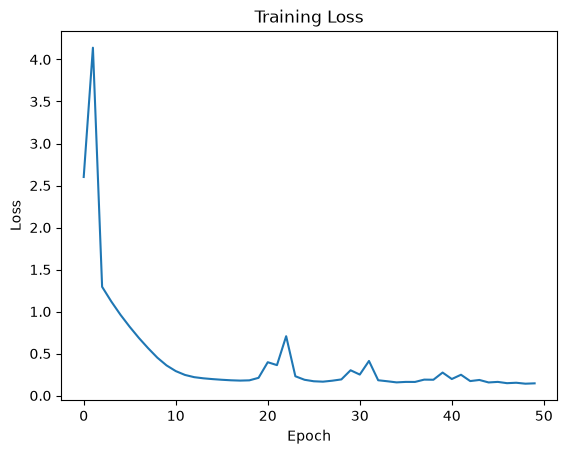

In [ ]:
plt.figure()
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

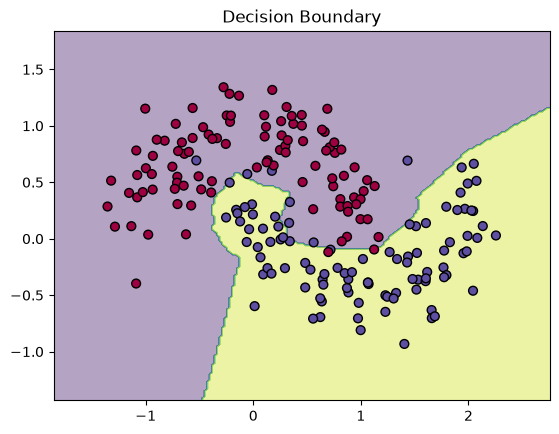

In [ ]:
# Decision boundary
def plot_decision_boundary(model, X, y, steps=200, padding=0.5):
    with torch.no_grad():
        x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
        y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding
        xx = torch.linspace(x_min, x_max, steps)
        yy = torch.linspace(y_min, y_max, steps)
        grid_x, grid_y = torch.meshgrid(xx, yy, indexing="xy")
        grid = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)
        probs, _ = model.forward(grid)
        Z = (probs > 0.5).long().reshape(steps, steps)

    plt.figure()
    plt.contourf(grid_x.numpy(), grid_y.numpy(), Z.numpy(), alpha=0.4)
    plt.scatter(
        X[:, 0].numpy(),
        X[:, 1].numpy(),
        c=y.view(-1).numpy(),
        s=40,
        cmap=plt.cm.Spectral,
        edgecolors="k",
    )
    plt.title("Decision Boundary")
    plt.show()


plot_decision_boundary(model, X, y)

## Optimize with torch SGD


In [ ]:
model = MLP([D, 32, 32, 1], manual_optimization=False)  # output_dim=1
epochs = 50
lr = 0.1

In [ ]:
torch_SGD = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
loss_hist = []

for epoch in range(1, epochs + 1):
    probs, _ = model.forward(X)
    loss = model.loss(y, probs)
    loss.backward()
    torch_SGD.step()
    loss_hist.append(loss.item())
    torch_SGD.zero_grad()

    if epoch % 2 == 0:
        with torch.no_grad():
            pred = model.predict(X)
            acc = (pred.view(-1) == y.view(-1).long()).float().mean().item() * 100
        print(f"Epoch {epoch:4d} | loss: {loss.item():.4f} | acc: {acc:.2f}%")

Epoch    2 | loss: 6.5113 | acc: 72.50%
Epoch    4 | loss: 1.2478 | acc: 81.00%
Epoch    6 | loss: 1.4325 | acc: 85.50%
Epoch    8 | loss: 0.5333 | acc: 88.00%
Epoch   10 | loss: 0.4477 | acc: 88.50%
Epoch   12 | loss: 0.6196 | acc: 82.50%
Epoch   14 | loss: 0.4782 | acc: 89.50%
Epoch   16 | loss: 0.3883 | acc: 88.00%
Epoch   18 | loss: 0.5757 | acc: 83.00%
Epoch   20 | loss: 0.4278 | acc: 91.50%
Epoch   22 | loss: 0.2762 | acc: 93.00%
Epoch   24 | loss: 0.2443 | acc: 89.00%
Epoch   26 | loss: 0.4469 | acc: 78.00%
Epoch   28 | loss: 0.4468 | acc: 92.00%
Epoch   30 | loss: 0.2311 | acc: 94.00%
Epoch   32 | loss: 0.1825 | acc: 93.50%
Epoch   34 | loss: 0.2345 | acc: 86.00%
Epoch   36 | loss: 0.3346 | acc: 88.50%
Epoch   38 | loss: 0.2071 | acc: 94.00%
Epoch   40 | loss: 0.1534 | acc: 94.00%
Epoch   42 | loss: 0.1555 | acc: 92.00%
Epoch   44 | loss: 0.2278 | acc: 85.00%
Epoch   46 | loss: 0.2483 | acc: 92.50%
Epoch   48 | loss: 0.1446 | acc: 94.50%
Epoch   50 | loss: 0.1228 | acc: 95.00%


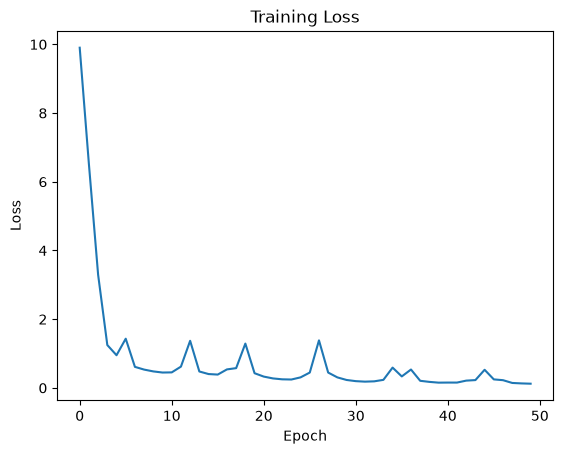

In [ ]:
plt.figure()
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

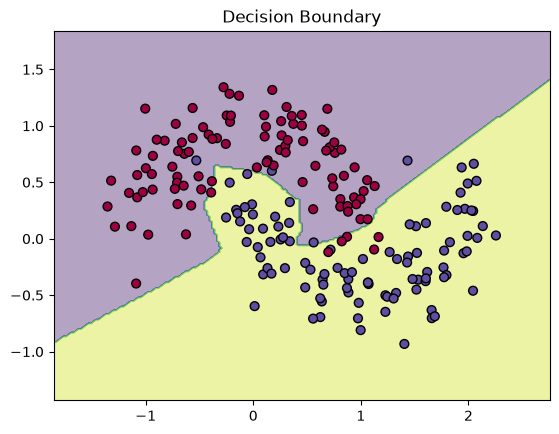

In [ ]:
plot_decision_boundary(model, X, y)